In [1]:
# compute disc implicit connectives metrics

# for each doc: tanh (num of unique connective types / num of types)
# averaged across docs

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

DISCOURSE_RELS_DIR = Path('/mimer/NOBACKUP/groups/naiss2025-22-1187/coherence-driven-humans/data/res60_v2/')
ROBERTA_EXCLUDED_STORY_IDS = [1214, 3761, 5047, 5540, 7195, 10499]


In [3]:
def normalize_story_id(raw_id):
    # formatting of story id
    s = str(raw_id).replace('story_', '')
    parts = s.split('_')
    if len(parts) >= 2 and parts[0] == 'doc':
        s = parts[1]
    try:
        return int(float(s))
    except (ValueError, TypeError):
        return None

def load_rels_data():
    all_data = []
    for folder in DISCOURSE_RELS_DIR.iterdir():
        if not folder.is_dir():
            continue
        rels_path = folder / "eng.pdtb.gum" / "eng.pdtb.gum_test.rels"
        if not rels_path.exists():
            continue
        # the output of the classifer produced a specific format
        parts = folder.name.split('_')
        model = parts[0]
        prompt = parts[1] if len(parts) > 1 else 'unknown'
        seed = parts[2] if len(parts) > 2 else None
        df = pd.read_csv(rels_path, sep='\t')
        df['model'] = model
        df['prompt'] = prompt
        df['seed'] = seed
        df['source_folder'] = folder.name
        all_data.append(df)
    return pd.concat(all_data, ignore_index=True)

def compute_discourse_diversity(df):
    prediction_col = 'prediction' if 'prediction' in df.columns else 'label'
    results = []
    groups = df.groupby(['model', 'prompt', 'seed', 'doc'], dropna=False)
    for (model, prompt, seed, doc), story_df in groups:
        relations = story_df[prediction_col].tolist()
        n_total = len(relations)
        n_none = sum(1 for r in relations if r in ['NONE', 'none', None, ''])
        valid_relations = [r for r in relations if r not in ['NONE', 'none', None, '']]

        if len(valid_relations) == 0:
            diversity_ratio = 0.0
            n_unique = 0
        else:
            n_unique = len(set(valid_relations))
            diversity_ratio = np.tanh(n_unique / len(valid_relations))

        none_rate = (n_none / n_total) if n_total > 0 else 0.0

        results.append({
            'model': model, 'prompt': prompt, 'seed': seed, 'doc': doc,
            'n_unique_relations': n_unique, 'n_total_relations': n_total,
            'n_none_relations': n_none, 'none_rate': none_rate,
            'discourse_diversity': diversity_ratio
        })
    return pd.DataFrame(results)

In [4]:
def prepare_discourse_data(diversity_df, excluded_story_ids=None):
    # averaging across human seeds
    results = []
    for model in diversity_df['model'].unique():
        for prompt in diversity_df['prompt'].unique():
            subset = diversity_df[(diversity_df['model'] == model) & 
                                  (diversity_df['prompt'] == prompt)]
            if subset.empty:
                continue
            seeds = subset['seed'].dropna().unique()
            if len(seeds) > 1:
                story_avg = subset.groupby('doc').agg({
                    'n_unique_relations': 'mean',
                    'n_total_relations': 'mean',
                    'n_none_relations': 'mean',
                    'none_rate': 'mean',
                    'discourse_diversity': 'mean'
                }).reset_index()
                for _, row in story_avg.iterrows():
                    results.append({
                        'model': model, 'prompt': prompt, 'story_id': normalize_story_id(row['doc']),
                        'n_unique_relations': row['n_unique_relations'],
                        'n_total_relations': row['n_total_relations'],
                        'n_none_relations': row['n_none_relations'],
                        'none_rate': row['none_rate'],
                        'discourse_diversity': row['discourse_diversity']
                    })
            else:
                for _, row in subset.iterrows():
                    results.append({
                        'model': model, 'prompt': prompt, 'story_id': normalize_story_id(row['doc']),
                        'n_unique_relations': row['n_unique_relations'],
                        'n_total_relations': row['n_total_relations'],
                        'n_none_relations': row['n_none_relations'],
                        'none_rate': row['none_rate'],
                        'discourse_diversity': row['discourse_diversity']
                    })
    result = pd.DataFrame(results)
    result['story_id'] = result['story_id'].astype(int)

    if excluded_story_ids:
        excluded_story_ids = {int(x) for x in excluded_story_ids}
        result = result[~result['story_id'].isin(excluded_story_ids)].copy()

    return result

In [5]:
df_rels_raw = load_rels_data()

In [6]:
df_diversity_raw = compute_discourse_diversity(df_rels_raw)

In [7]:
df_discourse = prepare_discourse_data(df_diversity_raw)
df_discourse_54 = prepare_discourse_data(df_diversity_raw, excluded_story_ids=ROBERTA_EXCLUDED_STORY_IDS)

In [8]:
df_discourse.head()

,model,prompt,story_id,n_unique_relations,n_total_relations,n_none_relations,none_rate,discourse_diversity
0,claude45,large,10408,1.0,5.0,0.0,0.0,0.197375
1,claude45,large,10486,1.0,5.0,0.0,0.0,0.197375
2,claude45,large,10499,1.0,4.0,0.0,0.0,0.244919
3,claude45,large,1111,3.0,4.0,0.0,0.0,0.635149
4,claude45,large,11260,2.0,4.0,0.0,0.0,0.462117


In [9]:
df_discourse_54.head()

,model,prompt,story_id,n_unique_relations,n_total_relations,n_none_relations,none_rate,discourse_diversity
0,claude45,large,10408,1.0,5.0,0.0,0.0,0.197375
1,claude45,large,10486,1.0,5.0,0.0,0.0,0.197375
3,claude45,large,1111,3.0,4.0,0.0,0.0,0.635149
4,claude45,large,11260,2.0,4.0,0.0,0.0,0.462117
5,claude45,large,11340,1.0,4.0,0.0,0.0,0.244919


In [10]:
# discourse aggregate metrics on original prompt
df_original_60 = df_discourse[df_discourse['prompt'] == 'original'].copy()

discourse_agg_original_60 = (
    df_original_60.groupby('model')
    .agg(
        n_unique_relations=('n_unique_relations', 'mean'),
        n_total_relations=('n_total_relations', 'mean'),
        n_none_relations=('n_none_relations', 'mean'),
        none_rate=('none_rate', 'mean'),
        discourse_diversity_mean=('discourse_diversity', 'mean'),
        discourse_diversity_std=('discourse_diversity', 'std'),
        count=('discourse_diversity', 'count')
    )
    .reset_index()
    .sort_values('model')
)

# discourse aggregate metrics on original prompt, 54
df_original_54 = df_discourse_54[df_discourse_54['prompt'] == 'original'].copy()

discourse_agg_original_54 = (
    df_original_54.groupby('model')
    .agg(
        n_unique_relations=('n_unique_relations', 'mean'),
        n_total_relations=('n_total_relations', 'mean'),
        n_none_relations=('n_none_relations', 'mean'),
        none_rate=('none_rate', 'mean'),
        discourse_diversity_mean=('discourse_diversity', 'mean'),
        discourse_diversity_std=('discourse_diversity', 'std'),
        count=('discourse_diversity', 'count')
    )
    .reset_index()
    .sort_values('model')
)

# discourse aggregate metrics on large prompt, 54
df_large_54 = df_discourse_54[df_discourse_54['prompt'] == 'large'].copy()

discourse_agg_large_54 = (
    df_large_54.groupby('model')
    .agg(
        n_unique_relations=('n_unique_relations', 'mean'),
        n_total_relations=('n_total_relations', 'mean'),
        n_none_relations=('n_none_relations', 'mean'),
        none_rate=('none_rate', 'mean'),
        discourse_diversity_mean=('discourse_diversity', 'mean'),
        discourse_diversity_std=('discourse_diversity', 'std'),
        count=('discourse_diversity', 'count')
    )
    .reset_index()
    .sort_values('model')
)

In [11]:
discourse_agg_original_60

,model,n_unique_relations,n_total_relations,n_none_relations,none_rate,discourse_diversity_mean,discourse_diversity_std,count
0,claude45,2.133333,4.666667,0.0,0.0,0.434063,0.131916,60
1,gpt4o,2.016667,4.600000,0.0,0.0,0.412273,0.149802,60
2,human,2.400000,4.783333,0.0,0.0,0.462533,0.145981,60
3,internvl3,1.833333,4.950000,0.0,0.0,0.352538,0.149605,60
4,llama4scout,1.916667,4.650000,0.0,0.0,0.391748,0.151668,60
5,qwen3vl,1.700000,4.666667,0.0,0.0,0.352892,0.145571,60


In [12]:
discourse_agg_large_54

,model,n_unique_relations,n_total_relations,n_none_relations,none_rate,discourse_diversity_mean,discourse_diversity_std,count
0,claude45,2.129630,4.814815,0.0,0.0,0.419547,0.135111,54
1,gpt4o,1.870370,4.777778,0.0,0.0,0.379519,0.134728,54
2,human,2.117284,4.759259,0.0,0.0,0.411672,0.115241,54
3,internvl3,1.777778,5.111111,0.0,0.0,0.343029,0.150219,54
4,llama4scout,1.981481,5.407407,0.0,0.0,0.358034,0.131741,54
5,qwen3vl,1.962963,4.777778,0.0,0.0,0.397515,0.133113,54


In [ ]:
discourse_agg_original_54

,model,n_unique_relations,n_total_relations,n_none_relations,none_rate,discourse_diversity_mean,discourse_diversity_std,count
0,claude45,2.166667,4.722222,0.0,0.0,0.437307,0.131009,54
1,gpt4o,2.055556,4.648148,0.0,0.0,0.415660,0.152912,54
2,human,2.388889,4.851852,0.0,0.0,0.454488,0.147789,54
3,internvl3,1.870370,4.981481,0.0,0.0,0.356950,0.153431,54
4,llama4scout,1.925926,4.703704,0.0,0.0,0.390291,0.153246,54
5,qwen3vl,1.666667,4.722222,0.0,0.0,0.343914,0.140792,54


In [14]:
import matplotlib.pyplot as plt
from pathlib import Path

MODEL_ORDER = ['human', 'claude45', 'gpt4o', 'internvl3', 'llama4scout', 'qwen3vl']
MODEL_LABELS = {
    'human': 'Human',
    'claude45': 'Claude 4.5',
    'gpt4o': 'GPT-4o',
    'internvl3': 'InternVL3',
    'llama4scout': 'Llama 4 Scout',
    'qwen3vl': 'Qwen3-VL'
}

def build_relation_type_story_counts(df, excluded_story_ids=None):
    prediction_col = 'prediction' if 'prediction' in df.columns else 'label'
    rel_df = df[['model', 'prompt', 'doc', prediction_col]].copy()
    rel_df = rel_df.rename(columns={prediction_col: 'relation_type'})
    rel_df['prompt'] = rel_df['prompt'].astype(str).str.strip().str.lower()
    rel_df['relation_type'] = rel_df['relation_type'].astype(str).str.strip()
    rel_df = rel_df[~rel_df['relation_type'].isin(['NONE', 'none', '', 'nan', 'None'])].copy()

    if excluded_story_ids:
        excluded_story_ids = {int(x) for x in excluded_story_ids}
        rel_df['story_id'] = rel_df['doc'].map(normalize_story_id)
        rel_df = rel_df[rel_df['story_id'].notna()].copy()
        rel_df['story_id'] = rel_df['story_id'].astype(int)
        rel_df = rel_df[~rel_df['story_id'].isin(excluded_story_ids)].copy()

    return rel_df

def resolve_prompt_value(summary_df, prompt_key):
    requested = str(prompt_key).strip().lower()
    available = set(summary_df['prompt'].dropna().astype(str).str.strip().str.lower().unique())

    if requested in available:
        return requested
    if requested == 'short' and 'original' in available:
        return 'original'
    raise ValueError(f"Prompt '{prompt_key}' not found. Available prompts: {sorted(available)}")

def plot_prompt_relation_composition(
    summary_df,
    prompt_key='short',
    save_path=None,
    annotate=True,
    relation_order=None,
    inside_label_fontsize=10,
    tiny_label_fontsize=9,
    inside_label_threshold=0.035,
    tiny_label_step=0.02,
    tiny_marker_size=115,
    tiny_marker_dx=0.0,
    tiny_marker_dy=0.004,
    tiny_text_dx=0.03
):
    resolved_prompt = resolve_prompt_value(summary_df, prompt_key)
    prompt_df = summary_df[summary_df['prompt'] == resolved_prompt].copy()

    if relation_order is None:
        relation_order = (
            prompt_df.groupby('relation_type')['mean_rel_count']
            .mean()
            .sort_values(ascending=False)
            .index
            .tolist()
        )

    matrix = (
        prompt_df.pivot(index='model', columns='relation_type', values='mean_rel_count')
        .reindex(index=MODEL_ORDER, columns=relation_order)
        .fillna(0.0)
    )

    proportions = matrix.div(matrix.sum(axis=1), axis=0).fillna(0.0)

    fig, ax = plt.subplots(figsize=(18, 10))
    cmap = plt.get_cmap('tab20')
    bottoms = np.zeros(len(proportions.index))
    x_pos = np.arange(len(proportions.index))
    bar_width = 0.9
    tiny_labels_by_bar = {i: [] for i in range(len(x_pos))}

    for idx, col in enumerate(proportions.columns):
        vals = proportions[col].values
        rel_color = cmap(idx % 20)
        bars = ax.bar(
            x_pos,
            vals,
            width=bar_width,
            bottom=bottoms,
            label=col,
            color=rel_color,
            edgecolor='white',
            linewidth=0.7
        )
        if annotate:
            for j, (bar, v) in enumerate(zip(bars, vals)):
                if v <= 0:
                    continue
                text = f'{v * 100:.1f}%'
                y_center = bottoms[j] + v / 2
                if v >= inside_label_threshold:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        y_center,
                        text,
                        ha='center',
                        va='center',
                        fontsize=inside_label_fontsize,
                        color='black'
                    )
                else:
                    tiny_labels_by_bar[j].append((y_center, text, rel_color))
        bottoms += vals

    if annotate:
        for j, tiny_items in tiny_labels_by_bar.items():
            if not tiny_items:
                continue
            tiny_items = sorted(tiny_items, key=lambda x: x[0])
            x_anchor = x_pos[j] + bar_width / 2
            x_text = x_anchor + 0.08
            y_text = 1.005
            for y_center, text, rel_color in tiny_items:
                marker_x = x_text + tiny_marker_dx
                marker_y = y_text + tiny_marker_dy
                ax.scatter(
                    [marker_x],
                    [marker_y],
                    s=tiny_marker_size,
                    marker='s',
                    c=[rel_color],
                    edgecolors='none',
                    zorder=5,
                    clip_on=False
                )
                ax.annotate(
                    text,
                    xy=(x_anchor, y_center),
                    xytext=(x_text + tiny_text_dx, y_text),
                    textcoords='data',
                    ha='left',
                    va='bottom',
                    color='black',
                    fontsize=tiny_label_fontsize,
                    arrowprops=dict(arrowstyle='-', lw=0.7, color='0.35')
                )
                y_text += tiny_label_step

    ax.set_xticks(x_pos)
    ax.set_xticklabels([MODEL_LABELS[m] for m in proportions.index], fontsize=20)
    ax.set_ylim(0, 1.10)
    ax.set_xlim(-0.75, len(x_pos) - 0.15)
    ax.grid(axis='y', color='0.85', linewidth=0.8)
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], title='Relation type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=25, title_fontsize=25)
    ax.tick_params(axis='y', labelsize=25)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()
    return matrix, proportions

story_relation_counts_60 = build_relation_type_story_counts(df_rels_raw, excluded_story_ids=None)

all_relation_types = (
    story_relation_counts_60['relation_type']
    .dropna()
    .astype(str)
    .str.strip()
    .loc[lambda s: ~s.isin(['NONE', 'none', '', 'nan', 'None'])]
    .unique()
    .tolist()
)

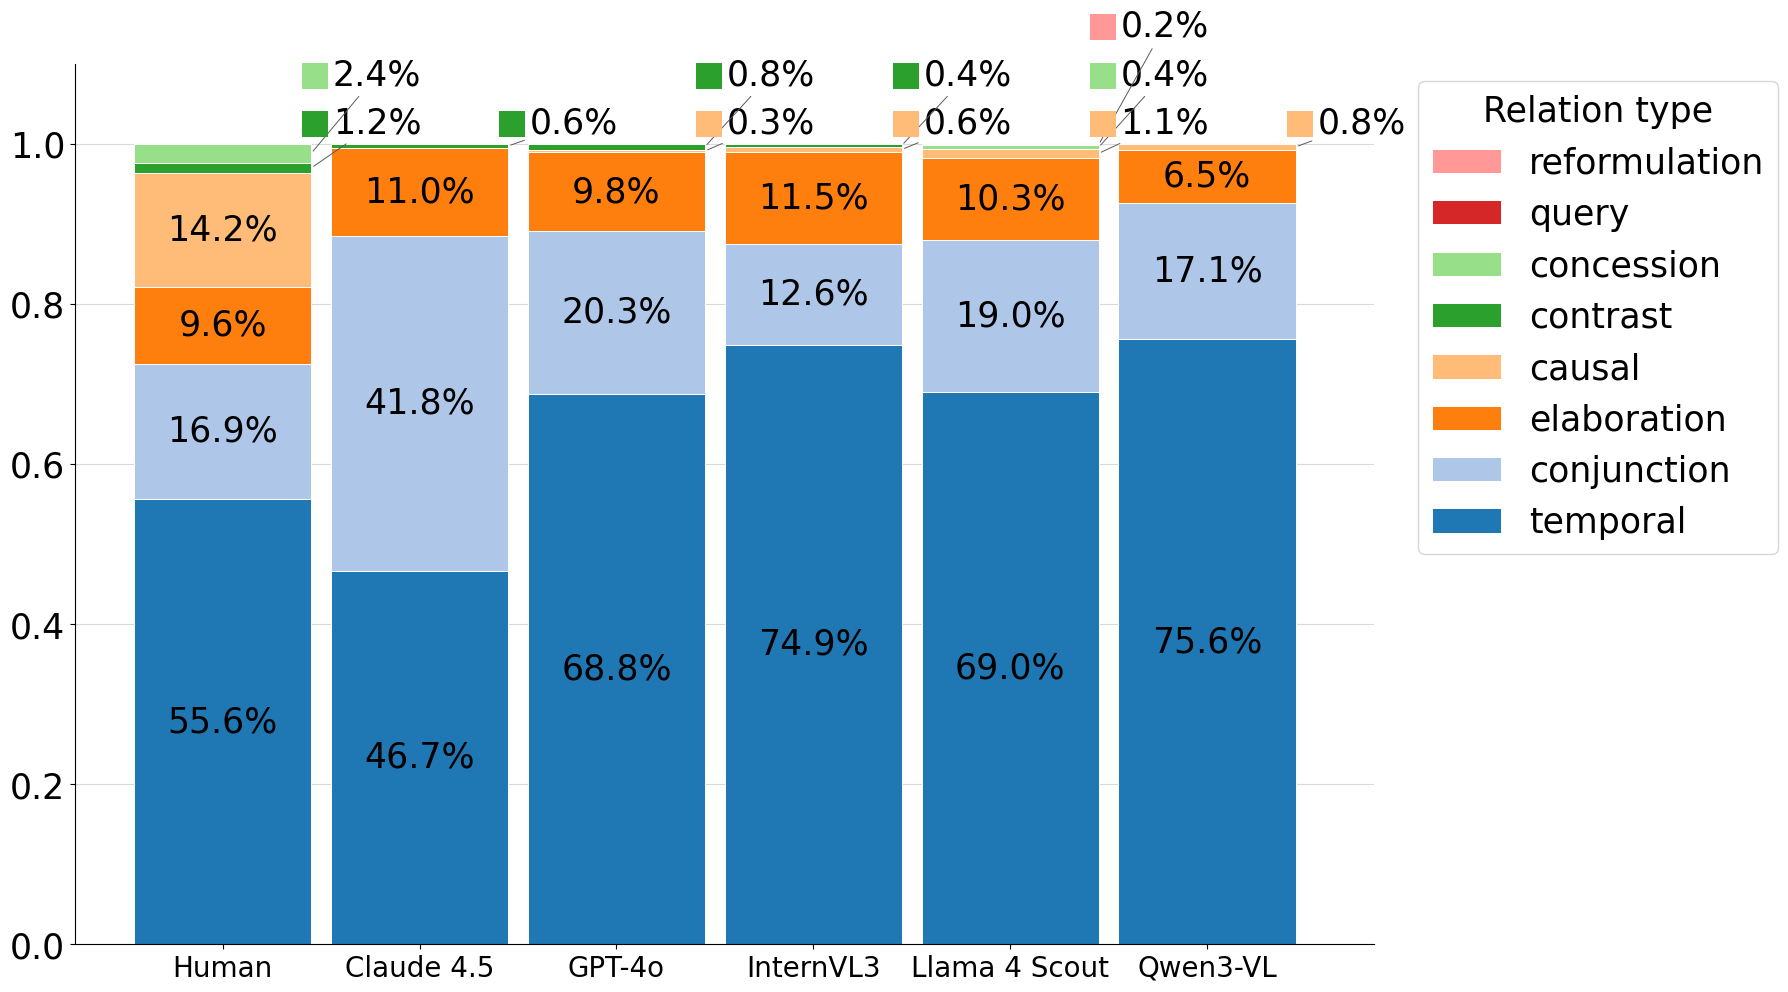

In [15]:
def summarize_mean_within_story_proportions(story_level_df, relation_types_all=None):
    counts = (
        story_level_df.groupby(['model', 'prompt', 'doc', 'relation_type'])
        .size()
        .reset_index(name='rel_count')
    )

    docs = story_level_df[['model', 'prompt', 'doc']].drop_duplicates()
    if relation_types_all is None:
        relation_types = sorted(story_level_df['relation_type'].dropna().unique().tolist())
    else:
        relation_types = [str(r).strip() for r in relation_types_all if str(r).strip()]

    rels = pd.DataFrame({'relation_type': relation_types})
    full_grid = docs.merge(rels, how='cross')

    counts_full = (
        full_grid.merge(counts, on=['model', 'prompt', 'doc', 'relation_type'], how='left')
        .fillna({'rel_count': 0.0})
    )

    counts_full['doc_total_relations'] = (
        counts_full.groupby(['model', 'prompt', 'doc'])['rel_count'].transform('sum')
    )
    counts_full['within_doc_prop'] = np.where(
        counts_full['doc_total_relations'] > 0,
        counts_full['rel_count'] / counts_full['doc_total_relations'],
        0.0
    )

    return (
        counts_full.groupby(['model', 'prompt', 'relation_type'])['within_doc_prop']
        .mean()
        .reset_index(name='mean_within_doc_prop')
    )

relation_prop_summary_60 = summarize_mean_within_story_proportions(
    story_relation_counts_60,
    relation_types_all=all_relation_types
)

global_relation_order = (
    relation_prop_summary_60.groupby('relation_type')['mean_within_doc_prop']
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

relation_prop_summary_for_plot = relation_prop_summary_60.rename(
    columns={'mean_within_doc_prop': 'mean_rel_count'}
)

composition_pdf_path_60 = Path(
    './analysis_data/implicit_connectives/figures/relation_type_composition_short_60_100pct_within_story_mean.pdf'
)
composition_matrix_60, composition_prop_60 = plot_prompt_relation_composition(
    relation_prop_summary_for_plot,
    prompt_key='short',
    save_path=composition_pdf_path_60,
    annotate=True,
    relation_order=global_relation_order,
    inside_label_fontsize=25,
    tiny_label_fontsize=25,
    inside_label_threshold=0.035,
    tiny_label_step=0.06,
    tiny_marker_size=350,
    tiny_marker_dy=0.020,
    tiny_marker_dx=-0.060
)


In [16]:
from scipy.stats import ttest_rel

def paired_ttests_human_vs_models_story_level(df, prompt='original', metric_col='discourse_diversity'):
    rows = []
    df_prompt = df[df['prompt'] == prompt].copy()
    df_human = df_prompt[df_prompt['model'] == 'human'].set_index('story_id')

    for model in MODEL_ORDER:
        if model == 'human':
            continue
        df_model = df_prompt[df_prompt['model'] == model].set_index('story_id')
        common_ids = sorted(df_human.index.intersection(df_model.index))

        if len(common_ids) < 2:
            rows.append({'model': model, 'n': len(common_ids), 't_stat': np.nan, 'p_value': np.nan})
            continue

        human_vals = df_human.loc[common_ids, metric_col].values
        model_vals = df_model.loc[common_ids, metric_col].values
        t_stat, p_value = ttest_rel(human_vals, model_vals)

        rows.append({
            'model': model,
            'n': len(common_ids),
            't_stat': float(t_stat),
            'p_value': float(p_value)
        })

    return pd.DataFrame(rows).sort_values('model').reset_index(drop=True)

def format_p(p):
    if pd.isna(p):
        return 'NA'
    if p < 0.001:
        return '<.001'
    return f'={p:.3f}'

implicit_ttest_original_60 = paired_ttests_human_vs_models_story_level(
    df_discourse,
    prompt='original',
    metric_col='discourse_diversity'
)

display(
    implicit_ttest_original_60.assign(
        t_stat=implicit_ttest_original_60['t_stat'].map(lambda x: np.nan if pd.isna(x) else round(x, 2)),
        p_value=implicit_ttest_original_60['p_value'].map(lambda x: np.nan if pd.isna(x) else round(x, 3))
    )
)

,model,n,t_stat,p_value
0,claude45,60,1.19,0.237
1,gpt4o,60,1.95,0.056
2,internvl3,60,4.33,0.000
3,llama4scout,60,2.63,0.011
4,qwen3vl,60,4.50,0.000


In [17]:
# n_total_relations per story and summary by model/prompt

n_rels_story = df_discourse[['model', 'prompt', 'story_id', 'n_total_relations']].copy()

n_rels_summary = (
    n_rels_story.groupby(['model', 'prompt'])['n_total_relations']
    .agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    .reset_index()
)

print('n_total_relations summary by model/prompt:')
n_rels_summary


n_total_relations summary by model/prompt:


,model,prompt,count,mean,std,min,median,max
0,claude45,large,60,4.750000,1.216065,4.0,4.0,8.0
1,claude45,original,60,4.666667,1.188457,2.0,4.0,8.0
2,gpt4o,large,60,4.716667,1.194502,4.0,4.0,8.0
3,gpt4o,original,60,4.600000,0.994902,4.0,4.0,8.0
4,human,large,60,4.700000,1.155842,4.0,4.0,8.0
5,human,original,60,4.783333,1.366570,4.0,4.0,9.0
6,internvl3,large,60,5.116667,1.530389,1.0,5.0,10.0
7,internvl3,original,60,4.950000,1.111191,3.0,5.0,8.0
8,llama4scout,large,60,5.300000,1.690452,3.0,5.0,10.0
9,llama4scout,original,60,4.650000,1.232677,1.0,4.0,9.0


In [18]:
implicit_ttest_original_54 = paired_ttests_human_vs_models_story_level(
    df_discourse_54,
    prompt='original',
    metric_col='discourse_diversity'
)

implicit_ttest_large_54 = paired_ttests_human_vs_models_story_level(
    df_discourse_54,
    prompt='large',
    metric_col='discourse_diversity'
)

display(implicit_ttest_original_60)
display(implicit_ttest_original_54)
display(implicit_ttest_large_54)

,model,n,t_stat,p_value
0,claude45,60,1.193810,0.237330
1,gpt4o,60,1.948271,0.056144
2,internvl3,60,4.327326,0.000059
3,llama4scout,60,2.633036,0.010787
4,qwen3vl,60,4.500209,0.000032


,model,n,t_stat,p_value
0,claude45,54,0.693460,0.491049
1,gpt4o,54,1.383071,0.172442
2,internvl3,54,3.557029,0.000800
3,llama4scout,54,2.278448,0.026757
4,qwen3vl,54,4.222279,0.000095


,model,n,t_stat,p_value
0,claude45,54,-0.310885,0.757108
1,gpt4o,54,1.646730,0.105531
2,internvl3,54,2.997208,0.004140
3,llama4scout,54,2.141811,0.036823
4,qwen3vl,54,0.733052,0.466757


In [19]:
discdata_path = Path('./analysis_data/implicit_connectives/')
discdata_path.mkdir(parents=True, exist_ok=True)

df_rels_raw.to_csv(discdata_path / 'rels_raw.csv', index=False)
df_diversity_raw.to_csv(discdata_path / 'discourse_diversity_raw.csv', index=False)
df_discourse.to_csv(discdata_path / 'discourse_metrics.csv', index=False)
discourse_agg_original_60.to_csv(discdata_path / 'discourse_metrics_agg_original_60.csv', index=False)

df_discourse_54.to_csv(discdata_path / 'discourse_metrics_54.csv', index=False)
discourse_agg_original_54.to_csv(discdata_path / 'discourse_metrics_agg_original_54.csv', index=False)
discourse_agg_large_54.to_csv(discdata_path / 'discourse_metrics_agg_large_54.csv', index=False)

implicit_ttest_original_60.to_csv(discdata_path / 'discourse_ttest_original_60.csv', index=False)
implicit_ttest_original_54.to_csv(discdata_path / 'discourse_ttest_original_54.csv', index=False)
implicit_ttest_large_54.to_csv(discdata_path / 'discourse_ttest_large_54.csv', index=False)